In [86]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


## Load Dataset

This dataset contains information about houses in the Delhi NCR region.
The objective is to predict the selling price using property features.

In [87]:
#Load Dataset
df=pd.read_csv('/Users/tejasmac/ML Projects/Delhi NCR House Price Prediction/data/housing_cleaned.csv')

In [88]:
#Exploratory Data Analysis (EDA)
print(df.head())

        price  bhk  area_sqft  parking
0   9500000.0  3.0     1400.0      0.0
1  57500000.0  3.0     1400.0      0.0
2   4000000.0  3.0     1400.0      0.0
3  13800000.0  4.0     1400.0      0.0
4  11000000.0  4.0     1400.0      0.0


In [89]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      12000 non-null  float64
 1   bhk        12000 non-null  float64
 2   area_sqft  12000 non-null  float64
 3   parking    12000 non-null  float64
dtypes: float64(4)
memory usage: 375.1 KB
None


In [90]:
print(df.describe())

              price           bhk      area_sqft       parking
count  1.200000e+04  12000.000000   12000.000000  12000.000000
mean   3.153475e+07      3.089917    1640.961417      0.691583
std    5.002292e+07      0.932597    2229.662233      0.461859
min    7.500000e+05      1.000000      32.000000      0.000000
25%    7.700000e+06      3.000000     900.000000      0.000000
50%    1.865000e+07      3.000000    1400.000000      1.000000
75%    3.470000e+07      4.000000    1900.000000      1.000000
max    1.500000e+09     12.000000  109000.000000      1.000000


In [91]:
print(df.isna().sum())

price        0
bhk          0
area_sqft    0
parking      0
dtype: int64


In [92]:
df.corr(numeric_only=True)

,price,bhk,area_sqft,parking
price,1.000000,0.428959,0.570488,-0.019280
bhk,0.428959,1.000000,0.344074,0.012147
area_sqft,0.570488,0.344074,1.000000,-0.001240
parking,-0.019280,0.012147,-0.001240,1.000000


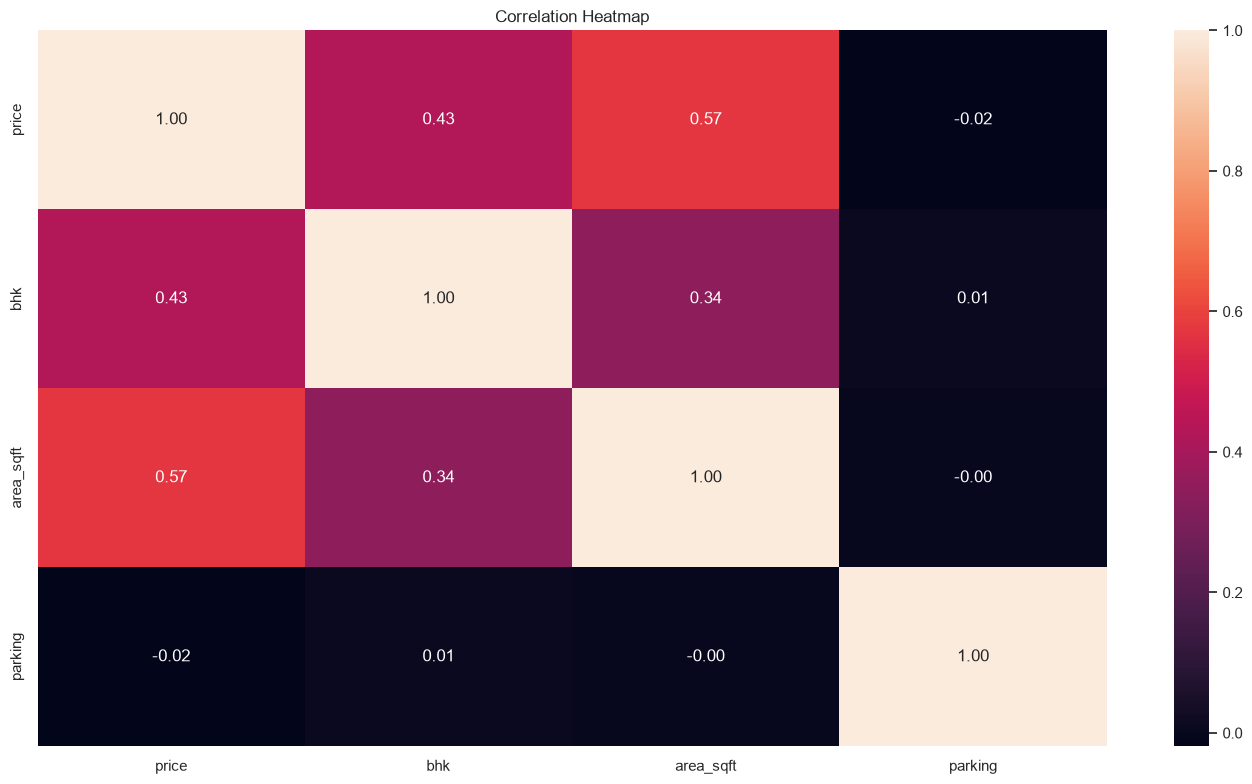

<Figure size 640x480 with 0 Axes>

In [93]:
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

plt.savefig("../outputs/correlation_heatmap.png", dpi=300, bbox_inches="tight")

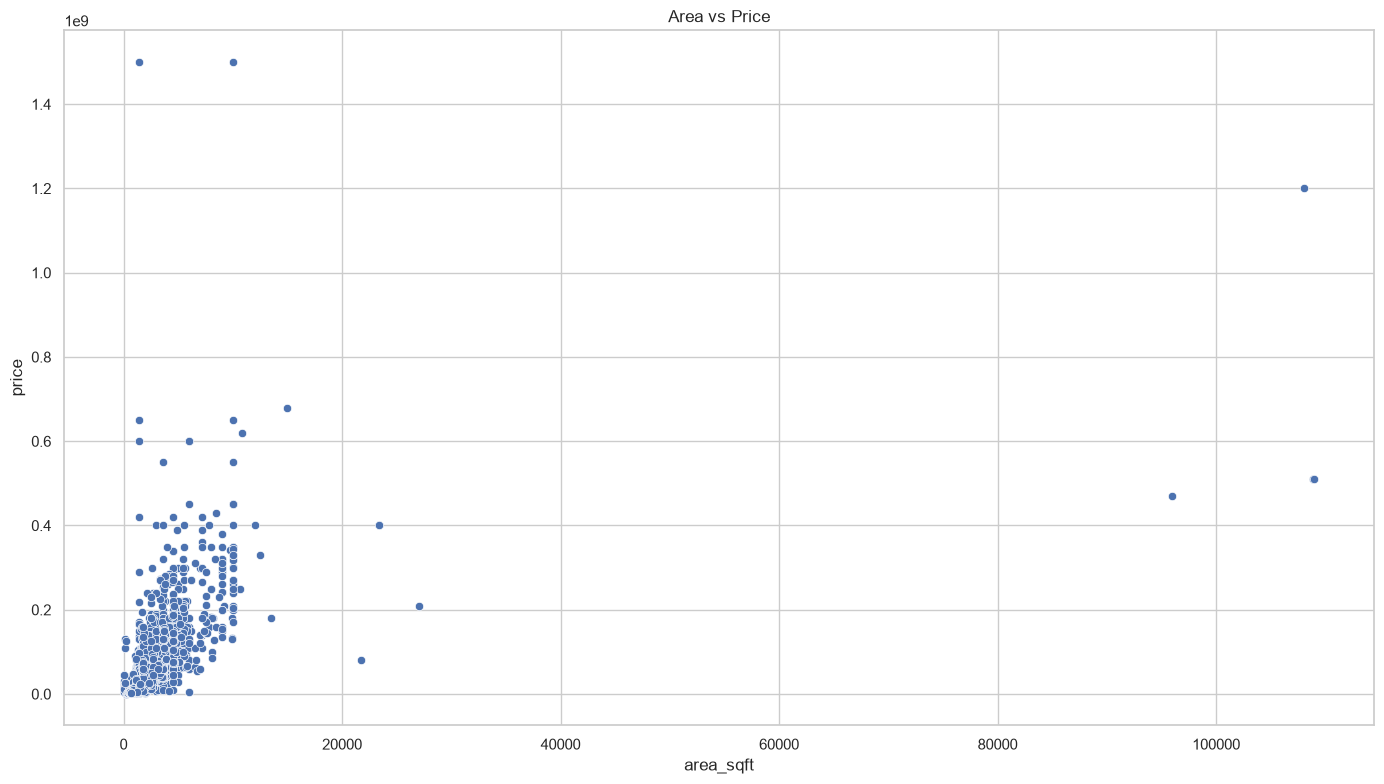

In [94]:
#Area vs Price
plt.figure(figsize=(14,8))

sns.scatterplot(x="area_sqft",y="price",data=df)

plt.title("Area vs Price")

plt.tight_layout()

plt.savefig("../outputs/area_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


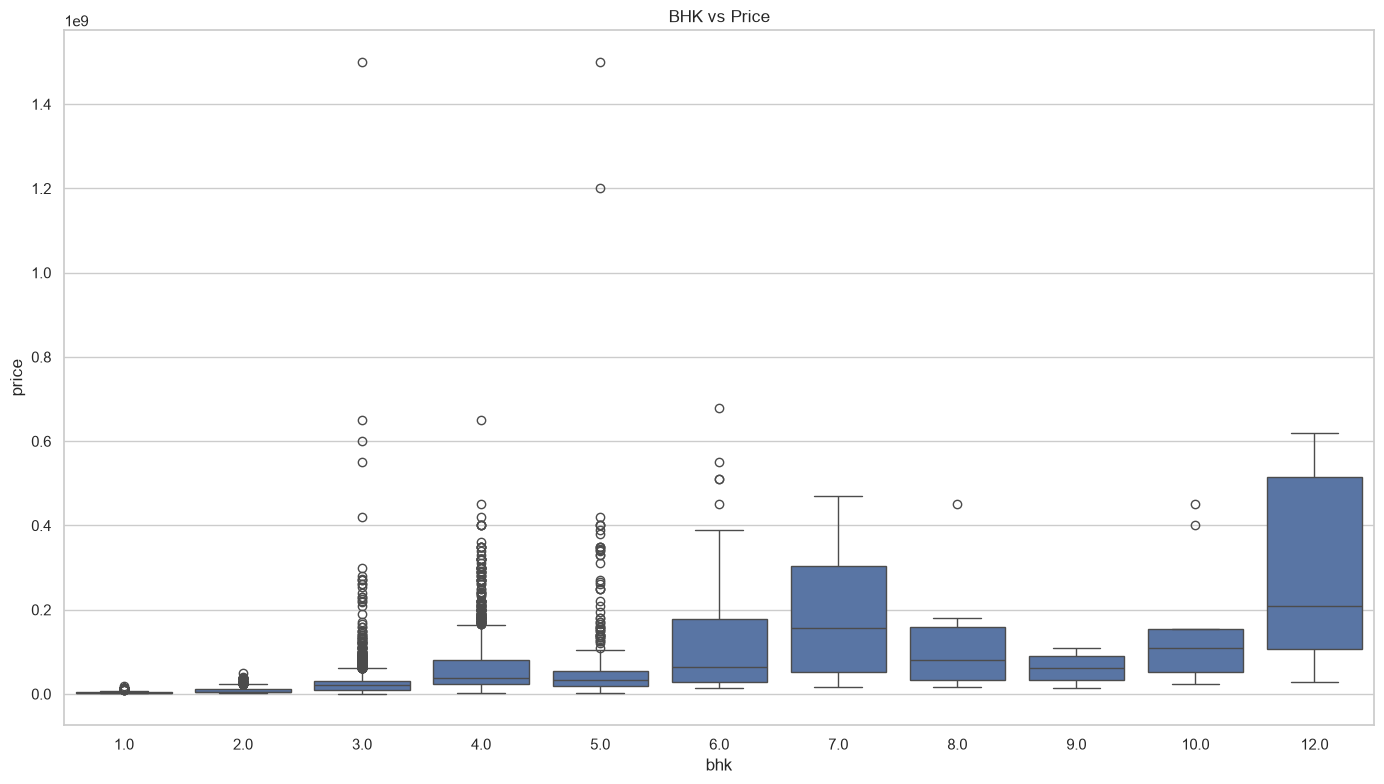

In [95]:
#BHK vs Price
plt.figure(figsize=(14,8))

sns.boxplot(data=df, x="bhk", y="price")

plt.title("BHK vs Price")

plt.tight_layout()
plt.savefig("../outputs/bhk_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

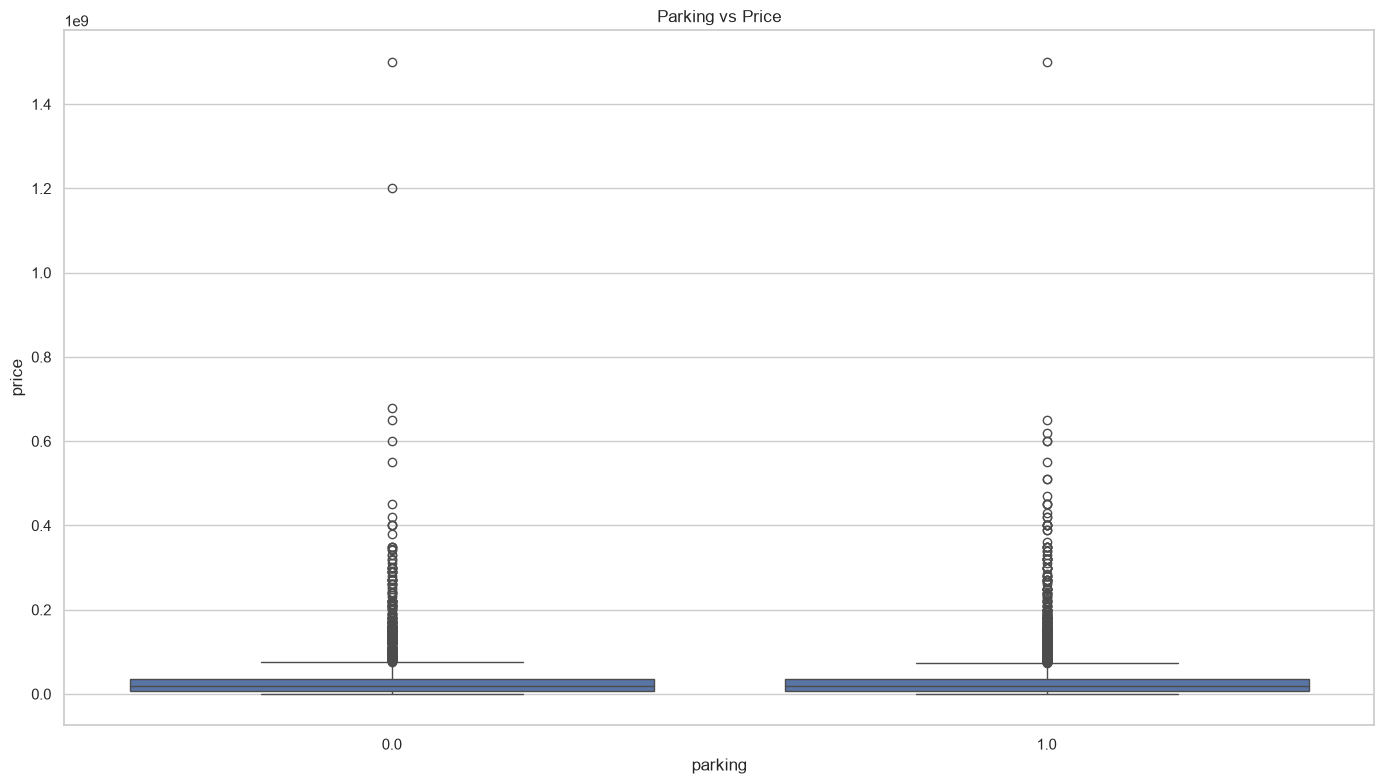

In [96]:
#Parking vs Price
plt.figure(figsize=(14,8))

sns.boxplot(data=df, x="parking", y="price")

plt.title("Parking vs Price")

plt.tight_layout()

plt.savefig("../outputs/parking_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

In [97]:
# Feature Selection
X=df[["area_sqft","bhk","parking"]]
y=df["price"]

## Train-Test Split

The dataset is divided into training and testing data.

Training Data → Used to teach the model.

Testing Data → Used to evaluate the model on unseen houses.

In [98]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [99]:
# Model Making
from sklearn.linear_model import LinearRegression

model=LinearRegression()

In [100]:
# Model Training
model.fit(X_train,y_train)
print("Model trained successfully!✅")

Model trained successfully!✅


In [101]:
# Model Prediction
y_pred=model.predict(X_test)
print(y_pred)

[51378707.66336057  3190019.6408685  23110245.28400827 ...
 29763933.17682449 -9094372.61107708 51378707.66336057]


In [102]:
comparison=pd.DataFrame({"Actual Price": [y_test],
                         "Real Price": [y_pred]})

print(comparison.head())


                                        Actual Price  \
0  7163      24000000.0
10385      8890000.0
1902...   

                                          Real Price  
0  [51378707.663360566, 3190019.6408685036, 23110...  


## Model Evaluation

The model is evaluated using:

- MAE
- RMSE
- R² Score

These metrics help us understand prediction accuracy.

In [114]:
# Model Evaluation
from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(y_test,y_pred)

print(f"MAE : ₹{mae:,.2f}")

MAE : ₹18,250,087.85


In [104]:
df["price"].describe()

count    1.200000e+04
mean     3.153475e+07
std      5.002292e+07
min      7.500000e+05
25%      7.700000e+06
50%      1.865000e+07
75%      3.470000e+07
max      1.500000e+09
Name: price, dtype: float64

In [121]:
from sklearn.metrics import mean_squared_error

mse=mean_squared_error(y_test,y_pred)

rmse=np.sqrt(mse)

print(f"MSE:{mse:.1f}")
print(f"RMSE:{rmse:.3f}")

MSE:1815152557956527.0
RMSE:42604607.239


In [117]:
from sklearn.metrics import r2_score

r2=r2_score(y_test,y_pred)
print(f"R² Score : {r2:.3f}")

R² Score : 0.350


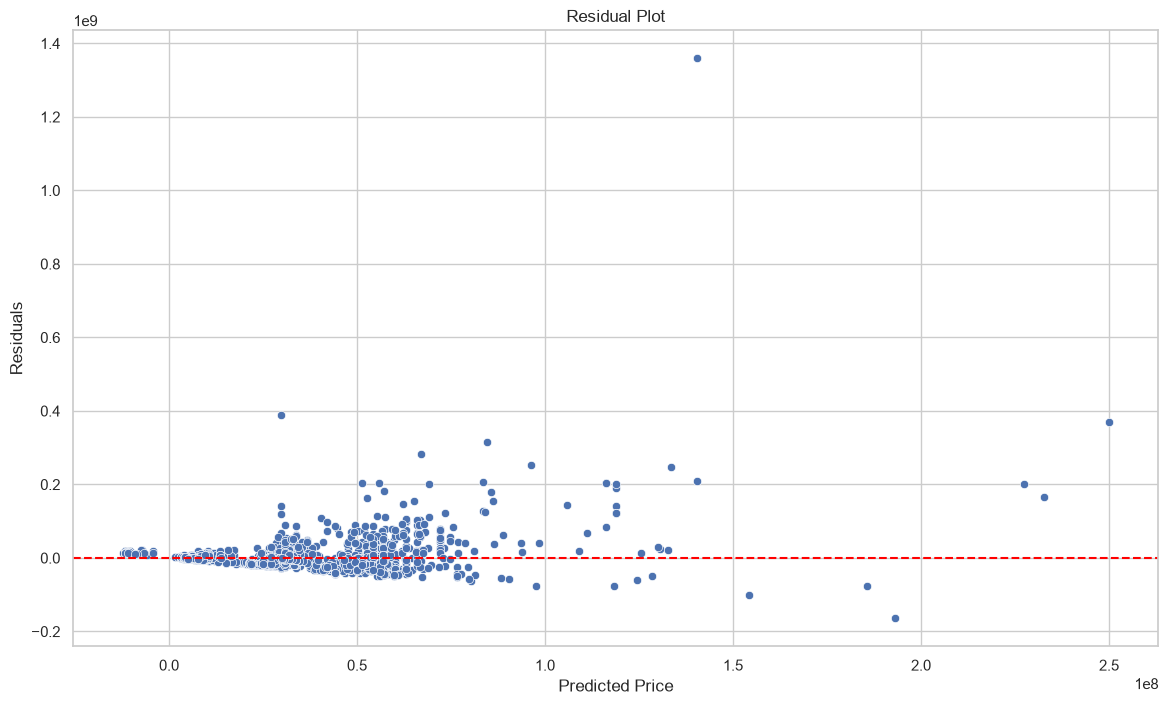

<Figure size 640x480 with 0 Axes>

In [107]:
# Residual Analysis
# Residual Plot

plt.figure(figsize=(14,8))

residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

plt.savefig("../outputs/residual_plot.png", dpi=300, bbox_inches="tight")


In [ ]:
# User Prediction
area = float(input("Enter Area (sq ft): "))
bhk = int(input("Enter BHK: "))
parking = int(input("Enter Parking: "))

new_house = pd.DataFrame({
    "area_sqft": [area],
    "bhk": [bhk],
    "parking": [parking]
})

prediction = model.predict(new_house)

print("----------- Prediction -----------")
print(f"Area      : {area} sq ft")
print(f"BHK       : {bhk}")
print(f"Parking   : {parking}")
print("----------------------------------")
print(f"Estimated Price : ₹{prediction[0]:,.0f}")


----------- Prediction -----------
Area      : 960.0 sq ft
BHK       : 2
Parking   : 1
----------------------------------
Estimated Price : ₹8,198,962


In [109]:
comparison.to_csv("../outputs/predictions.csv", index=False)

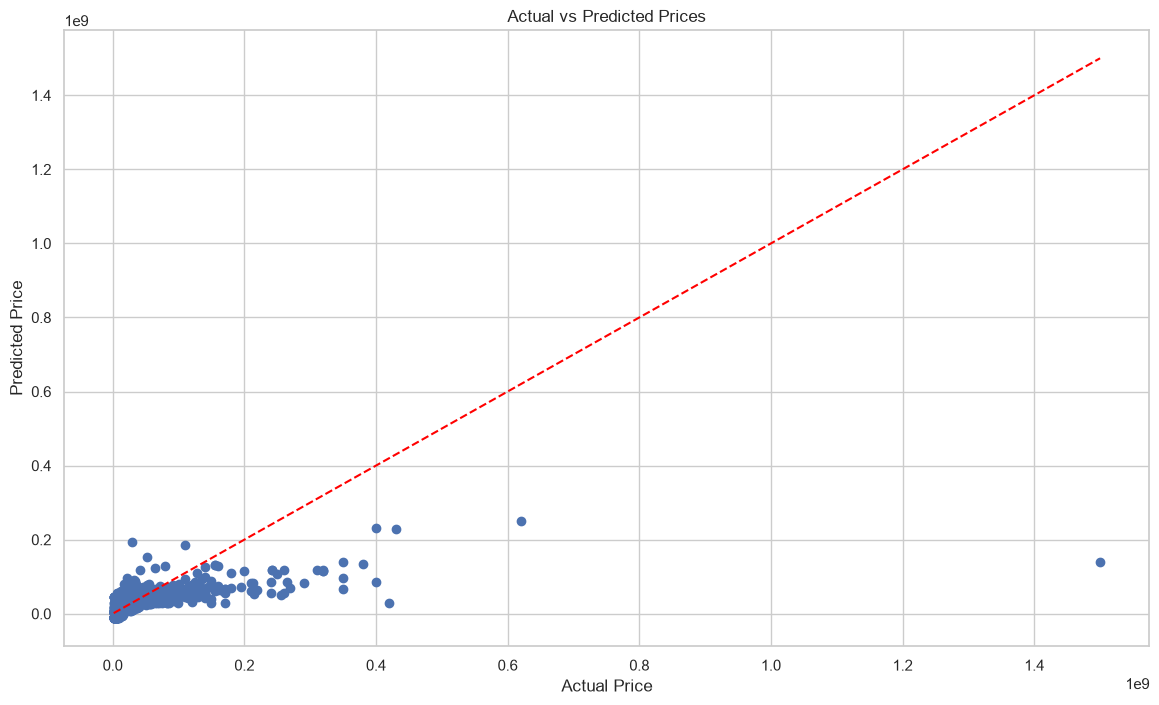

<Figure size 640x480 with 0 Axes>

In [110]:
#Actual vs Predicted
plt.figure(figsize=(14,8))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

plt.savefig("../outputs/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

In [111]:
# Save Model
import joblib

joblib.dump(model, "../models/house_price_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


## Conclusion

A Linear Regression model was successfully trained to predict house prices.

Performance:

- MAE: ₹18,250,087.85
- RMSE: 42604607.239
- R² Score: 0.350


The model provides a basic price prediction using Area, BHK, and Parking.

Future improvements include adding Location, Property Type, Property Age, and comparing advanced algorithms like Decision Tree and Random Forest.